<a href="https://colab.research.google.com/github/Naylet92/Estudio_ambiental/blob/main/San%20Gabriel/SGB_capas_entrenamieno_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Sierra de San Gabriel 2020
### Construcción del arrays NumPy de 1 capas para tres conjutos categoricos de referencia



In [2]:
# Prefijo del área
PREFIJO     = 'SGB'
# Nombre del área
NOMBRE      = 'San_Gabriel'

# Ruta de la carpeta de Drive donde estan los .tif exportados
#RUTA_TIF = '/content/drive/MyDrive/ANP/Landsat/SVerde_Landsat/SVD_tif-2000'
RUTA_TIF = '/content/drive/MyDrive/Colab Data NDC 2020'

YEAR        = 2020

file_names = [
    f"{PREFIJO}_{YEAR}_ref_CP.tif",
    f"{PREFIJO}_{YEAR}_ref_EC.tif",
    f"{PREFIJO}_{YEAR}_ref_DW.tif"
]

numpy_file_names = [
    f"{PREFIJO}_{YEAR}_ref_CP.npy",
    f"{PREFIJO}_{YEAR}_ref_EC.npy",
    f"{PREFIJO}_{YEAR}_ref_DW.npy"
]

# Carpeta local donde se guardaran los .npy y .json de salida
#RUTA_SALIDA ='/content/drive/MyDrive/ANP/Landsat/SVerde_Landsat/SVD_tif-2000/Nympy2000'
RUTA_SALIDA = '/content/drive/MyDrive/Colab Data NDC 2020/Numpy'

In [4]:
import os
#import glob
#import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt
#from sklearn.preprocessing import RobustScaler, StandardScaler
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(RUTA_SALIDA, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Leer datos Geo TIFF de referencia (categoricas)

Ahora, convertimos los GeoTIFFs de referencia en arrays NumPy usando la nueva función y mostramos un resumen de sus características.

In [5]:
for file_name in file_names:
    file_path = os.path.join(RUTA_TIF, file_name)
    print(f"\nProcessing file: {file_name}")

    try:
        with rasterio.open(file_path) as src:
            # Confirm geometry and CRS
            print(f"  Geometry (shape): {src.shape}")
            print(f"  CRS: {src.crs}")

            # Inspect statistics of categorical variable in the first band
            # Read the first band
            band1 = src.read(1)

            # Flatten the array to get all pixel values
            # Filter out no-data values if present, assuming 0 or np.nan could be no-data
            if src.nodata is not None:
                valid_data = band1[band1 != src.nodata]
            else:
                valid_data = band1[~np.isnan(band1)] # If nodata is not explicitly set, check for NaN

            if valid_data.size == 0:
                print("  No valid data found in the first band to analyze frequencies.")
                continue

            # Get unique values and their counts (frequencies)
            unique_classes, counts = np.unique(valid_data, return_counts=True)

            print("  Frequency table for first band:")
            print("  --------------------------------")
            for class_val, count in zip(unique_classes, counts):
                print(f"  Class {class_val}: {count} pixels")
            print("  --------------------------------")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred while processing {file_name}: {e}")


Processing file: SGB_2020_ref_CP.tif
  Geometry (shape): (464, 486)
  CRS: EPSG:32613
  Frequency table for first band:
  --------------------------------
  Class 20: 1704 pixels
  Class 30: 692 pixels
  Class 40: 10550 pixels
  Class 50: 574 pixels
  Class 111: 652 pixels
  Class 112: 33 pixels
  Class 114: 7826 pixels
  Class 115: 161524 pixels
  Class 116: 17353 pixels
  Class 125: 9 pixels
  Class 126: 24587 pixels
  --------------------------------

Processing file: SGB_2020_ref_EC.tif
  Geometry (shape): (464, 486)
  CRS: EPSG:32613
  Frequency table for first band:
  --------------------------------
  Class 0: 50702 pixels
  Class 1: 174802 pixels
  --------------------------------

Processing file: SGB_2020_ref_DW.tif
  Geometry (shape): (464, 486)
  CRS: EPSG:32613
  Frequency table for first band:
  --------------------------------
  Class 0: 55 pixels
  Class 1: 177914 pixels
  Class 2: 1584 pixels
  Class 4: 16090 pixels
  Class 5: 27791 pixels
  Class 6: 1840 pixels
  Cla

### Convertir GeoTIFFs a NumPy arrays y presentar resumen

In [6]:
tif_arrays = {}
tif_profiles = {}

def read_geotiff_data(path):
    # Reads a GeoTIFF file and returns the array (bands, H, W) in uint8
    # and its profile (metadata).
    with rasterio.open(path) as src:
        arr = src.read().astype('uint8')
        # Replace no-data values with NaN if defined (though typically not for uint8)
        if src.nodata is not None and not np.isnan(src.nodata):
            arr[arr == src.nodata] = 0 # Or some other no-data value appropriate for uint8
        profile = src.profile
    return arr, profile

for file_name in file_names:
    file_path = os.path.join(RUTA_TIF, file_name)
    print(f"\nProcesando archivo: {file_name}")

    try:
        arr, profile = read_geotiff_data(file_path)
        tif_arrays[file_name] = arr
        tif_profiles[file_name] = profile

        print(f"  Array shape: {arr.shape}")
        print(f"  Array dtype: {arr.dtype}")
        print(f"  CRS: {profile.get('crs')}")
        print(f"  Transform: {profile.get('transform')}")
        print(f"  Width: {profile.get('width')}")
        print(f"  Height: {profile.get('height')}")
        print(f"  Bands: {profile.get('count')}")

    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {file_path}")
    except Exception as e:
        print(f"Ocurrió un error al procesar {file_name}: {e}")


Procesando archivo: SGB_2020_ref_CP.tif
  Array shape: (1, 464, 486)
  Array dtype: uint8
  CRS: EPSG:32613
  Transform: | 30.00, 0.00, 634080.00|
| 0.00,-30.00, 2185200.00|
| 0.00, 0.00, 1.00|
  Width: 486
  Height: 464
  Bands: 1

Procesando archivo: SGB_2020_ref_EC.tif
  Array shape: (1, 464, 486)
  Array dtype: uint8
  CRS: EPSG:32613
  Transform: | 30.00, 0.00, 634080.00|
| 0.00,-30.00, 2185200.00|
| 0.00, 0.00, 1.00|
  Width: 486
  Height: 464
  Bands: 1

Procesando archivo: SGB_2020_ref_DW.tif
  Array shape: (1, 464, 486)
  Array dtype: uint8
  CRS: EPSG:32613
  Transform: | 30.00, 0.00, 634080.00|
| 0.00,-30.00, 2185200.00|
| 0.00, 0.00, 1.00|
  Width: 486
  Height: 464
  Bands: 1


# Visualizar los datos

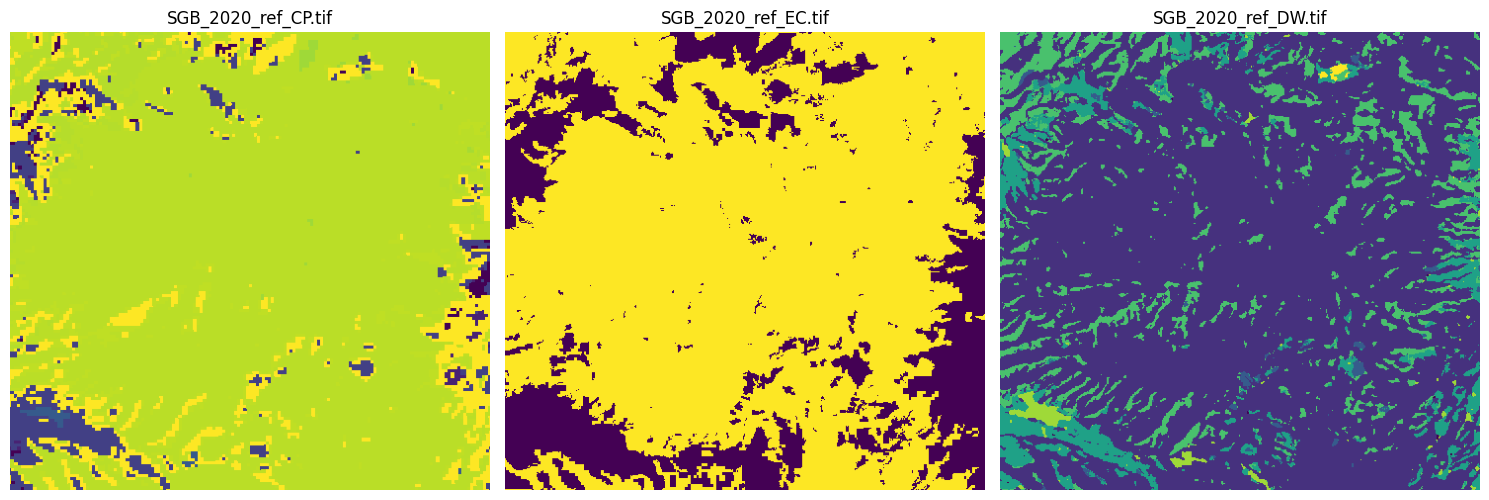

In [7]:
plt.figure(figsize=(15, 5))

for i, (file_name, arr) in enumerate(tif_arrays.items()):
    plt.subplot(1, len(tif_arrays), i + 1)
    # Assuming the first band is the one to be visualized
    # The array shape is (bands, height, width), so we take the first band (index 0)
    if arr.ndim == 3 and arr.shape[0] > 0:
        img_to_show = arr[0, :, :]
    elif arr.ndim == 2:
        img_to_show = arr
    else:
        print(f"Warning: {file_name} has an unexpected shape: {arr.shape}. Skipping visualization.")
        continue

    plt.imshow(img_to_show, cmap='viridis') # 'viridis' is a good default colormap for single-band images
    plt.title(file_name)
    plt.axis('off') # Hide axes for cleaner image display

plt.tight_layout()
plt.show()

## Guardar los arrays en la carpeta de salida

In [8]:
for i in range(len(file_names)):
    original_tif_name = file_names[i]
    numpy_output_name = numpy_file_names[i]
    array_to_save = tif_arrays[original_tif_name]

    save_path = os.path.join(RUTA_SALIDA, numpy_output_name)
    np.save(save_path, array_to_save)
    print(f"Guardado: {save_path}")

Guardado: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_ref_CP.npy
Guardado: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_ref_EC.npy
Guardado: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_ref_DW.npy
